# LogPress

### Data Loading

Load all log datasets and examine their formats.

In [ ]:
# Library imports
import re
import time
from pathlib import Path
from collections import Counter
from datetime import datetime

try:
    import pandas as pd
    import matplotlib.pyplot as plt
    import numpy as np

except ImportError:
    print("Installing dependencies...")
    %pip install pandas,numpy,matplotlib
    import pandas as pd
    import matplotlib.pyplot as plt
    import numpy as np
print("All libraries loaded.")

All libraries loaded.


In [4]:
# Dataset paths
DATASETS_DIR = Path("datasets")

DATASET_FILES = {
    "Apache": DATASETS_DIR / "Apache.log",
    #"BGL": DATASETS_DIR / "BGL.log",
    "Hadoop": DATASETS_DIR / "Hadoop.log",
    #"HDFS": DATASETS_DIR / "HDFS.log",
    "HealthApp": DATASETS_DIR / "HealthApp.log",
    "Linux": DATASETS_DIR / "Linux.log",
    "Mac": DATASETS_DIR / "Mac.log",
    "OpenSSH": DATASETS_DIR / "OpenSSH.log",
    "Openstack": DATASETS_DIR / "Openstack.log",
    #"Spark": DATASETS_DIR / "Spark.log",
    "Proxifier": DATASETS_DIR / "Proxifier.log",
    "Zookeeper": DATASETS_DIR / "Zookeeper.log",
}

# Verify all files exist
for name, path in DATASET_FILES.items():
    if path.exists():
        print(f"{name}: {path} (EXISTS)")
    else:
        print(f"{name}: {path} (MISSING)")

Apache: datasets/Apache.log (EXISTS)
Hadoop: datasets/Hadoop.log (EXISTS)
HealthApp: datasets/HealthApp.log (EXISTS)
Linux: datasets/Linux.log (EXISTS)
Mac: datasets/Mac.log (EXISTS)
OpenSSH: datasets/OpenSSH.log (EXISTS)
Openstack: datasets/Openstack.log (EXISTS)
Proxifier: datasets/Proxifier.log (EXISTS)
Zookeeper: datasets/Zookeeper.log (EXISTS)


In [5]:
# Functions to use in data loading
def load_logs(filepath):
    logs = []
    with open(filepath, "r", encoding="utf-8", errors="replace") as f:
        for line in f:
            line = line.rstrip("\n\r")
            if line:  # skip empty lines
                logs.append(line)
    return logs


def get_file_size_mb(filepath):
    return filepath.stat().st_size / (1024 * 1024)

In [6]:
# Load all datasets
datasets = {}

print("Loading datasets...\n")
print(f"{'Dataset':<12} {'Lines':>12} {'Size (MB)':>12}")
print("-" * 40)

total_lines = 0
total_size = 0

for name, path in DATASET_FILES.items():
    start = time.time()
    logs = load_logs(path)
    elapsed = time.time() - start
    
    size_mb = get_file_size_mb(path)
    datasets[name] = logs
    
    total_lines += len(logs)
    total_size += size_mb
    
    print(f"{name:<12} {len(logs):>12,} {size_mb:>12.1f}")

print("-" * 40)
print(f"{'TOTAL':<12} {total_lines:>12,} {total_size:>12.1f}")
print("\nAll datasets loaded.")

Loading datasets...

Dataset             Lines    Size (MB)
----------------------------------------
Apache             51,978          4.7
Hadoop            179,993         30.4
HealthApp         253,395         22.4
Linux              25,567          2.2
Mac               117,283         16.1
OpenSSH           638,947         67.3
Openstack         189,386         53.4
Proxifier          21,320          2.4
Zookeeper          74,273          9.9
----------------------------------------
TOTAL           1,552,142        208.9

All datasets loaded.


In [7]:
# Preview first 3 logs from each dataset we loaded
print("Log Format Samples\n")

for name, logs in datasets.items():
    print(f"=== {name} ===")
    for i in range(min(3, len(logs))):
        # Truncate long lines for display
        line = logs[i]
        if len(line) > 120:
            line = line[:120] + "..."
        print(f"  {line}")
    print()

Log Format Samples

=== Apache ===
  [Thu Jun 09 06:07:04 2005] [notice] LDAP: Built with OpenLDAP LDAP SDK
  [Thu Jun 09 06:07:04 2005] [notice] LDAP: SSL support unavailable
  [Thu Jun 09 06:07:04 2005] [notice] suEXEC mechanism enabled (wrapper: /usr/sbin/suexec)

=== Hadoop ===
  2015-10-17 21:48:16,337 INFO [main] org.apache.hadoop.metrics2.impl.MetricsConfig: loaded properties from hadoop-metrics...
  2015-10-17 21:48:16,509 INFO [main] org.apache.hadoop.metrics2.impl.MetricsSystemImpl: Scheduled snapshot period at 10 s...
  2015-10-17 21:48:16,509 INFO [main] org.apache.hadoop.metrics2.impl.MetricsSystemImpl: MapTask metrics system started

=== HealthApp ===
  20171223-22:15:29:606|Step_LSC|30002312|onStandStepChanged 3579
  20171223-22:15:29:615|Step_LSC|30002312|onExtend:1514038530000 14 0 4
  20171223-22:15:29:633|Step_StandReportReceiver|30002312|onReceive action: android.intent.action.SCREEN_ON

=== Linux ===
  Jun  9 06:06:20 combo syslogd 1.4.1: restart.
  Jun  9 06:06:20

In [8]:
# Statistics per dataset
stats = []

for name, logs in datasets.items():
    lengths = [len(log) for log in logs]
    stats.append({
        "Dataset": name,
        "Log Count": len(logs),
        "Min Length": min(lengths),
        "Max Length": max(lengths),
        "Avg Length": round(sum(lengths) / len(lengths), 1),
        "Total Chars": sum(lengths),
    })

stats_df = pd.DataFrame(stats)
print(stats_df.to_string(index=False))

  Dataset  Log Count  Min Length  Max Length  Avg Length  Total Chars
   Apache      51978          48         187        94.7      4923706
   Hadoop     179993          65         592       176.2     31707290
HealthApp     253395          48         294        90.9     23023140
    Linux      25567          29        1030        90.9      2324119
      Mac     117283           1        1314       141.8     16634140
  OpenSSH     638947          65         188       109.4     69897118
Openstack     189386         100         450       294.7     55816574
Proxifier      21320          91         224       117.2      2498071
Zookeeper      74273          75         387       138.1     10256034


### Section 2: Tokenization

Split logs into tokens. 
Tokenizer will handle those delimiters ( Spaces, Brackets [] () , Pipes | , Colons : , Equals = ).
Count Token Frequency and Distribution per dataset.

In [9]:
# Tokenization Function
def tokenize(logs):
    tokens = []
    current_token = ""
    
    i = 0
    # Delimiters: space/tab, brackets, pipes, colons, equals, commas
    bracket_delims = "[](){}"
    symbol_delims = "|:=,"
    whitespace = " \t"
    
    while i < len(logs):
        char = logs[i]
        
        if char in whitespace:
            if current_token:
                tokens.append(current_token)
                current_token = ""
        
        elif char in bracket_delims or char in symbol_delims:
            if current_token:
                tokens.append(current_token)
                current_token = ""
            tokens.append(char)
        
        else:
            current_token += char
        i += 1
    
    if current_token:
        tokens.append(current_token)
    
    return tokens

In [10]:
# Tokenize all unstructured logs
tokenized_datasets = {}

print("Tokenizing all datasets...\n")
print(f"{'Dataset':<12} {'Logs':>12} {'Total Tokens':>15} {'Avg Tokens/Log':>15}")
print("-" * 58)

for name, logs in datasets.items():
    start = time.time()
    tokenized_logs = [tokenize(log) for log in logs]
    elapsed = time.time() - start
    
    total_tokens = sum(len(t) for t in tokenized_logs)
    avg_tokens = total_tokens / len(logs) if logs else 0
    
    tokenized_datasets[name] = tokenized_logs
    
    print(f"{name:<12} {len(logs):>12,} {total_tokens:>15,} {avg_tokens:>15.1f}")

print("\nTokenization complete.")

Tokenizing all datasets...

Dataset              Logs    Total Tokens  Avg Tokens/Log
----------------------------------------------------------
Apache             51,978       1,205,915            23.2
Hadoop            179,993       4,584,261            25.5
HealthApp         253,395       4,277,624            16.9
Linux              25,567         612,978            24.0
Mac               117,283       3,059,934            26.1
OpenSSH           638,947      17,821,657            27.9
Openstack         189,386       6,462,675            34.1
Proxifier          21,320         550,401            25.8
Zookeeper          74,273       2,018,125            27.2

Tokenization complete.


In [11]:
# Token frequency

all_tokens = []
for name, tokenized_logs in tokenized_datasets.items():
    for tokens in tokenized_logs:
        all_tokens.extend(tokens)

token_counts = Counter(all_tokens)

print("Top 20 Most Common Tokens (across all datasets):\n")
print(f"{'Rank':<6} {'Token':<30} {'Count':>15}")
print("-" * 55)

for rank, (token, count) in enumerate(token_counts.most_common(20), 1):
    display_token = token if len(token) <= 28 else token[:25] + "..."
    print(f"{rank:<6} {display_token:<30} {count:>15,}")

Top 20 Most Common Tokens (across all datasets):

Rank   Token                                    Count
-------------------------------------------------------
1      :                                    6,394,751
2      [                                    1,679,160
3      ]                                    1,678,117
4      =                                    1,575,170
5      -                                      892,113
6      sshd                                   842,942
7      |                                      766,241
8      LabSZ                                  638,947
9      0                                      592,104
10     ,                                      491,266
11     root                                   392,410
12     INFO                                   379,544
13     (                                      376,010
14     )                                      375,238
15     Jan                                    361,675
16     for                    

### Semantic Type Detection

Classify tokens into semantic types using regex patterns.

The semanic types:

- TIMESTAMP: Date and time values
- IP_ADDRESS: IPv4 and IPv6 addresses
- SEVERITY: Log levels (INFO, WARN, ERROR, DEBUG, FATAL)
- NUMBER: Numeric values (integers, floats, hex)
- PATH: File paths and URLs
- PROCESS_ID: Process identifiers
- COMPONENT: Module and class names
- WORD: Regular words
- DELIMITER: Brackets, pipes, colons, equals

In [12]:
# Defining semantic patterns
# Each pattern is a tuple: (type_name, regex_pattern, priority)
# higher priority patterns are checked first

SEMANTIC_PATTERNS = [
    # Severity levels - check first as they are specific keywords
    ("SEVERITY", r"^(INFO|WARN|WARNING|ERROR|DEBUG|FATAL|TRACE|NOTICE|CRITICAL|SEVERE)$", 100),
    
    # IP addresses
    ("IP_ADDRESS", r"^(\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3})(:\d+)?$", 90),
    ("IP_ADDRESS", r"^([0-9a-fA-F:]+:+[0-9a-fA-F:]+)$", 90),  # IPv6
    
    # Timestamps - various formats
    ("TIMESTAMP", r"^\d{4}-\d{2}-\d{2}[T ]\d{2}:\d{2}:\d{2}", 85),  # ISO format
    ("TIMESTAMP", r"^\d{8}-\d{2}:\d{2}:\d{2}:\d{3}$", 85),  # HealthApp format
    ("TIMESTAMP", r"^(Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)\s+\d{1,2}$", 85),
    ("TIMESTAMP", r"^\d{2}:\d{2}:\d{2}(,\d{3})?$", 85),  # Time only
    ("TIMESTAMP", r"^\d{6}$", 60),  # HDFS format: 203518 (HHMMSS)
    ("TIMESTAMP", r"^\d{4}\.\d{2}\.\d{2}$", 85),  # 2005.06.03
    
    # File paths
    ("PATH", r"^(/[a-zA-Z0-9._-]+)+/?$", 80),
    ("PATH", r"^[a-zA-Z]:\\", 80),  # Windows path
    ("PATH", r"^https?://", 80),  # URL
    
    # Process/Thread IDs - numbers in brackets or after specific patterns
    ("PROCESS_ID", r"^\d+$", 40),  # Generic number, low priority
    
    # Hex values
    ("HEX", r"^0x[0-9a-fA-F]+$", 70),
    ("HEX", r"^[0-9a-fA-F]{8,}$", 50),  # Long hex string
    
    # Block IDs (HDFS specific)
    ("BLOCK_ID", r"^blk_-?\d+$", 75),
    
    # Delimiters
    ("DELIMITER", r"^[\[\](){}\|]$", 95),
    
    # Component and Module names - CamelCase or with dots
    ("COMPONENT", r"^[A-Z][a-zA-Z0-9]*(\.[A-Z][a-zA-Z0-9]*)+", 65),
    ("COMPONENT", r"^[a-z]+\.[a-z]+(\.[a-z]+)*$", 65),
    
    # Generic word
    ("WORD", r"^[a-zA-Z_][a-zA-Z0-9_]*$", 20),
    
    # Numbers (float)
    ("NUMBER", r"^-?\d+\.\d+$", 50),
    
    # Catch-all for remaining text
    ("OTHER", r".*", 0),
]

# Compile patterns for efficiency
COMPILED_PATTERNS = [(name, re.compile(pattern), priority) 
                     for name, pattern, priority in SEMANTIC_PATTERNS]

print(f"Defined {len(SEMANTIC_PATTERNS)} semantic type patterns.")

Defined 22 semantic type patterns.


In [13]:
# Classification function 
# Classify a token into semantic type and return the type name with the highest priority match.
# Classify list of (token, type) tuples

def classify_token(token):
    best_match = ("OTHER", 0)
    
    for type_name, pattern, priority in COMPILED_PATTERNS:
        if pattern.match(token):
            if priority > best_match[1]:
                best_match = (type_name, priority)
    
    return best_match[0]


def classify_tokens(tokens):
    return [(token, classify_token(token)) for token in tokens]

In [14]:
# Classify tokens for all datasets
classified_datasets = {}

print("Classifying tokens for all datasets...\n")

for name, tokenized_logs in tokenized_datasets.items():
    start = time.time()
    classified_logs = [classify_tokens(tokens) for tokens in tokenized_logs]
    elapsed = time.time() - start
    
    classified_datasets[name] = classified_logs
    print(f"{name}: {len(classified_logs):,} logs classified in {elapsed:.2f}s")

print("\nClassification complete.")

Classifying tokens for all datasets...

Apache: 51,978 logs classified in 3.88s
Hadoop: 179,993 logs classified in 17.53s
HealthApp: 253,395 logs classified in 15.45s
Linux: 25,567 logs classified in 2.16s
Mac: 117,283 logs classified in 10.50s
OpenSSH: 638,947 logs classified in 65.04s
Openstack: 189,386 logs classified in 22.82s
Proxifier: 21,320 logs classified in 1.98s
Zookeeper: 74,273 logs classified in 7.07s

Classification complete.


Semantic Type Distribution by Dataset:

Dataset     COMPONENT   DELIMITER   HEX         IP_ADDRESS  NUMBER      OTHER       PATH        PROCESS_ID  SEVERITY    TIMESTAMP   WORD        
------------------------------------------------------------------------------------------------------------------------------------------------
Apache      585         297,456     0           31,089      8           145,268     36,157      279,770     0           0           415,582     
Hadoop      4,083       466,817     59,671      382         46,417      1,503,766   4,526       998,558     180,483     1,087       1,318,471   
HealthApp   4,743       778,757     305,957     5           14,308      1,375,179   50          1,067,443   0           33,636      697,546     
Linux       516         67,852      496         5,832       465         153,078     292         152,718     4           311         231,414     
Mac         13,648      364,634     29,678      3,239       28,798      978,703     9,450 

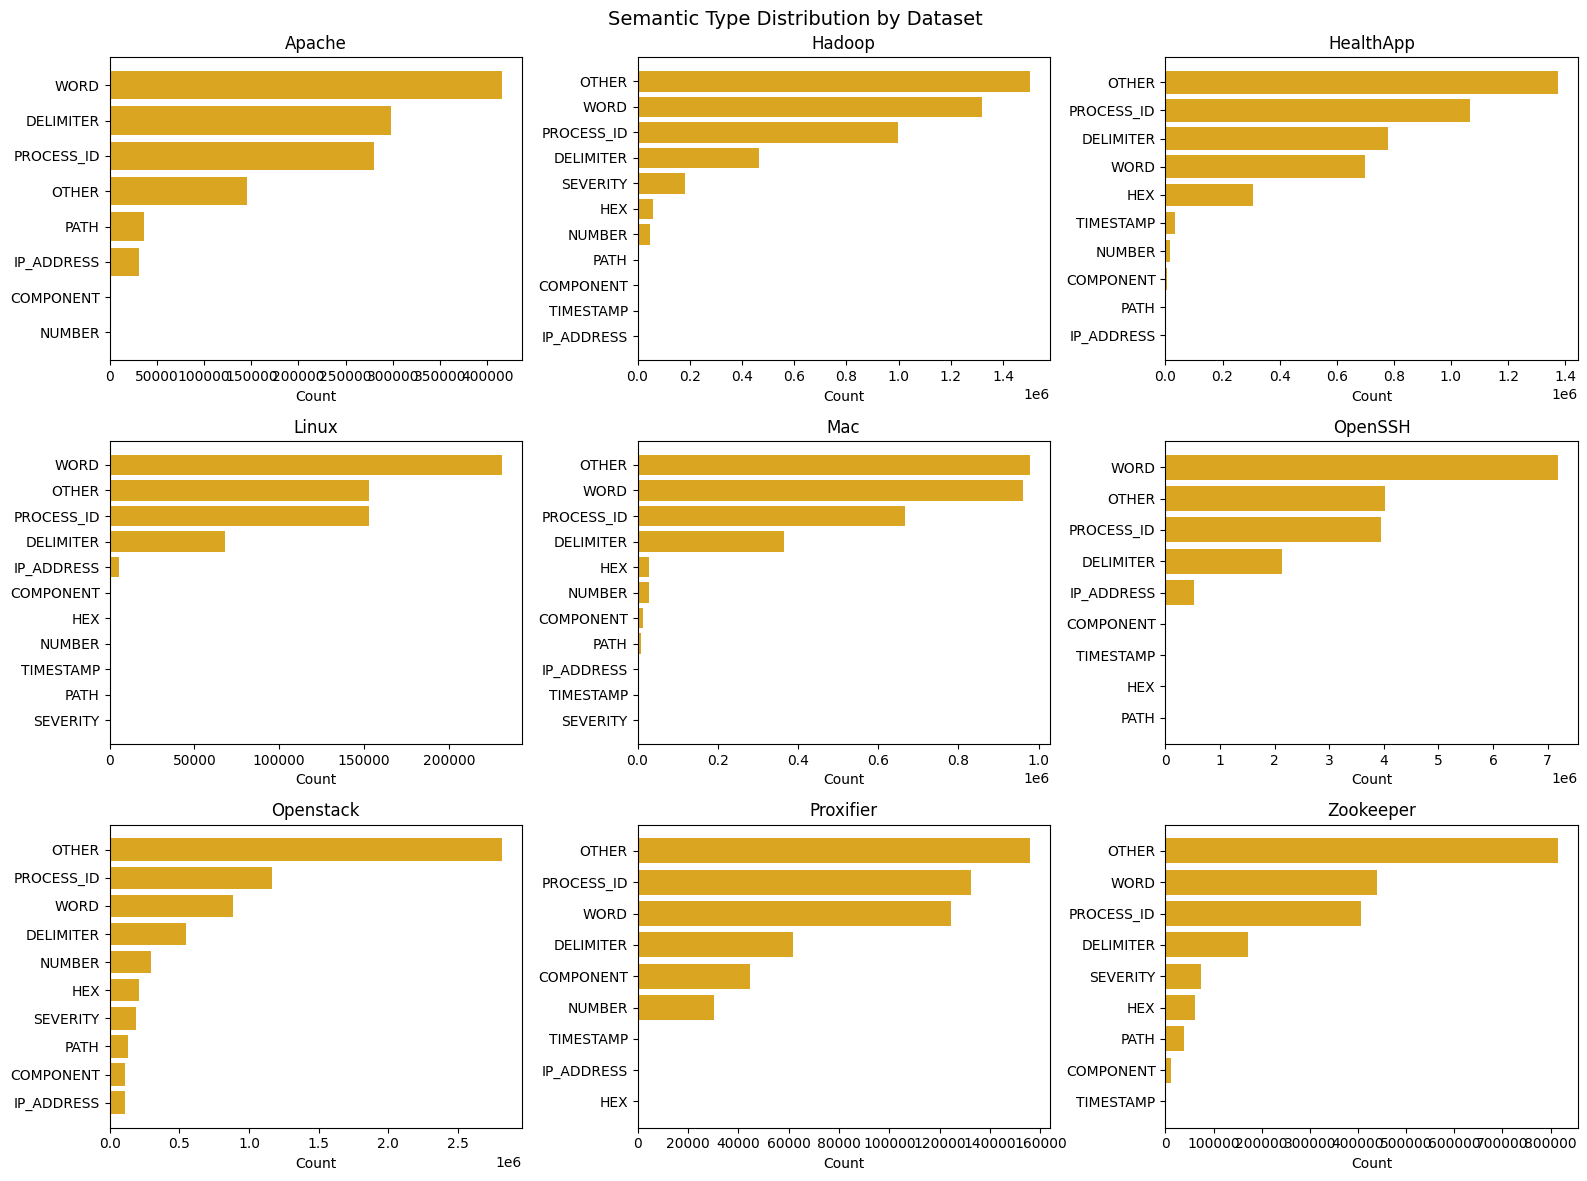

In [24]:
# Analyze semantic type distribution for all datasets and visualize results as a summary table and bar chart
type_distributions = {}

for name, classified_logs in classified_datasets.items():
    type_counts = Counter()
    for log in classified_logs:
        for token, token_type in log:
            type_counts[token_type] += 1
    type_distributions[name] = type_counts

# Create summary table
all_types = set()
for counts in type_distributions.values():
    all_types.update(counts.keys())
all_types = sorted(all_types)

print("Semantic Type Distribution by Dataset:\n")
header = f"{'Dataset':<12}" + "".join(f"{t:<12}" for t in all_types)
print(header)
print("-" * len(header))

for name in type_distributions:
    row = f"{name:<12}"
    for t in all_types:
        count = type_distributions[name].get(t, 0)
        row += f"{count:<12,}"
    print(row)

# Visualize as bar charts
num_datasets = len(type_distributions)
cols = 3
rows = (num_datasets + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
axes = axes.flatten()

for idx, name in enumerate(type_distributions.keys()):
    ax = axes[idx]
    counts = type_distributions[name]
    
    sorted_types = sorted(counts.items(), key=lambda x: x[1], reverse=True)
    types = [t[0] for t in sorted_types]
    values = [t[1] for t in sorted_types]
    
    ax.barh(types, values, color="goldenrod")
    ax.set_xlabel("Count")
    ax.set_title(f"{name}")
    ax.invert_yaxis()

for idx in range(num_datasets, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle("Semantic Type Distribution by Dataset", fontsize=14)
plt.tight_layout()
plt.show()

In [16]:
# Show classification examples from each dataset
print("Classification Examples:\n")

for name, classified_logs in classified_datasets.items():
    if len(classified_logs) > 0:
        sample_log = classified_logs[0]
        original_log = datasets[name][0]
        
        print(f"=== {name} ===")
        print(f"Original: {original_log[:100]}..." if len(original_log) > 100 else f"Original: {original_log}")
        print("Classified tokens:")
        for token, token_type in sample_log[:10]:
            print(f"  {token_type:<12} : {token}")
        if len(sample_log) > 10:
            print(f"  ... and {len(sample_log) - 10} more tokens")
        print()

Classification Examples:

=== Apache ===
Original: [Thu Jun 09 06:07:04 2005] [notice] LDAP: Built with OpenLDAP LDAP SDK
Classified tokens:
  DELIMITER    : [
  WORD         : Thu
  WORD         : Jun
  PROCESS_ID   : 09
  PROCESS_ID   : 06
  OTHER        : :
  PROCESS_ID   : 07
  OTHER        : :
  PROCESS_ID   : 04
  PROCESS_ID   : 2005
  ... and 11 more tokens

=== Hadoop ===
Original: 2015-10-17 21:48:16,337 INFO [main] org.apache.hadoop.metrics2.impl.MetricsConfig: loaded properties...
Classified tokens:
  OTHER        : 2015-10-17
  PROCESS_ID   : 21
  OTHER        : :
  PROCESS_ID   : 48
  OTHER        : :
  PROCESS_ID   : 16
  OTHER        : ,
  PROCESS_ID   : 337
  SEVERITY     : INFO
  DELIMITER    : [
  ... and 8 more tokens

=== HealthApp ===
Original: 20171223-22:15:29:606|Step_LSC|30002312|onStandStepChanged 3579
Classified tokens:
  OTHER        : 20171223-22
  OTHER        : :
  PROCESS_ID   : 15
  OTHER        : :
  PROCESS_ID   : 29
  OTHER        : :
  PROCESS_ID   

### Schema and template extraction

The algorithm looks at each token in a log and checks if it changes (like timestamps, IPs, numbers) or stays the same (like brackets, keywords).
Variable tokens are replaced with placeholders like `<TIMESTAMP>`, while constant tokens stay as it is, creating a template that groups similar logs together.

In [17]:
# Define semantic types are that variable (replaced with placeholders) and which are constant (kept in template)

VARIABLE_TYPES = {
    "TIMESTAMP",
    "IP_ADDRESS", 
    "PROCESS_ID",
    "NUMBER",
    "HEX",
    "BLOCK_ID",
    "PATH",
}

CONSTANT_TYPES = {
    "DELIMITER",
    "SEVERITY",
    "WORD",
    "COMPONENT",
    "OTHER",
}


def extract_template(classified_log):
    template_tokens = []
    
    for token, token_type in classified_log:
        if token_type in VARIABLE_TYPES:
            template_tokens.append(f"<{token_type}>")
        else:
            template_tokens.append(token)
    
    return tuple(template_tokens)


def template_to_string(template):
    return " ".join(template)

In [18]:
# Extract templates 
template_datasets = {}

print("Extracting templates for all datasets...\n")
print(f"{'Dataset':<12} {'Logs':>12} {'Unique Templates':>18}")
print("-" * 45)

for name, classified_logs in classified_datasets.items():
    start = time.time()
    
    templates = []
    for log in classified_logs:
        template = extract_template(log)
        templates.append(template)
    
    unique_templates = len(set(templates))
    elapsed = time.time() - start
    
    template_datasets[name] = templates
    
    print(f"{name:<12} {len(templates):>12,} {unique_templates:>18,}")

print("\nTemplate extraction complete.")

Extracting templates for all datasets...

Dataset              Logs   Unique Templates
---------------------------------------------
Apache             51,978              1,019
Hadoop            179,993             29,618
HealthApp         253,395             62,540
Linux              25,567              3,018
Mac               117,283             19,173
OpenSSH           638,947              6,617
Openstack         189,386            128,699
Proxifier          21,320              2,123
Zookeeper          74,273              2,577

Template extraction complete.


Template Analysis:

Dataset        Total Logs    Templates  Logs/Template   Top Template
--------------------------------------------------------------------
Apache             51,978        1,019           51.0           3.4%
Hadoop            179,993       29,618            6.1           2.9%
HealthApp         253,395       62,540            4.1           0.5%
Linux              25,567        3,018            8.5          21.7%
Mac               117,283       19,173            6.1           3.0%
OpenSSH           638,947        6,617           96.6          11.5%
Openstack         189,386      128,699            1.5           2.1%
Proxifier          21,320        2,123           10.0          19.7%
Zookeeper          74,273        2,577           28.8          14.0%


Top 5 Templates per Dataset:

=== Apache ===
  1. (1,748 logs, 3.4%) [ Sun Jan <PROCESS_ID> <PROCESS_ID> : <PROCESS_ID> : <PROCESS_ID> <PRO...
  2. (1,677 logs, 3.2%) [ Sat Jan <PROCESS_ID> <PROCESS_ID> : <PROCESS_ID> :

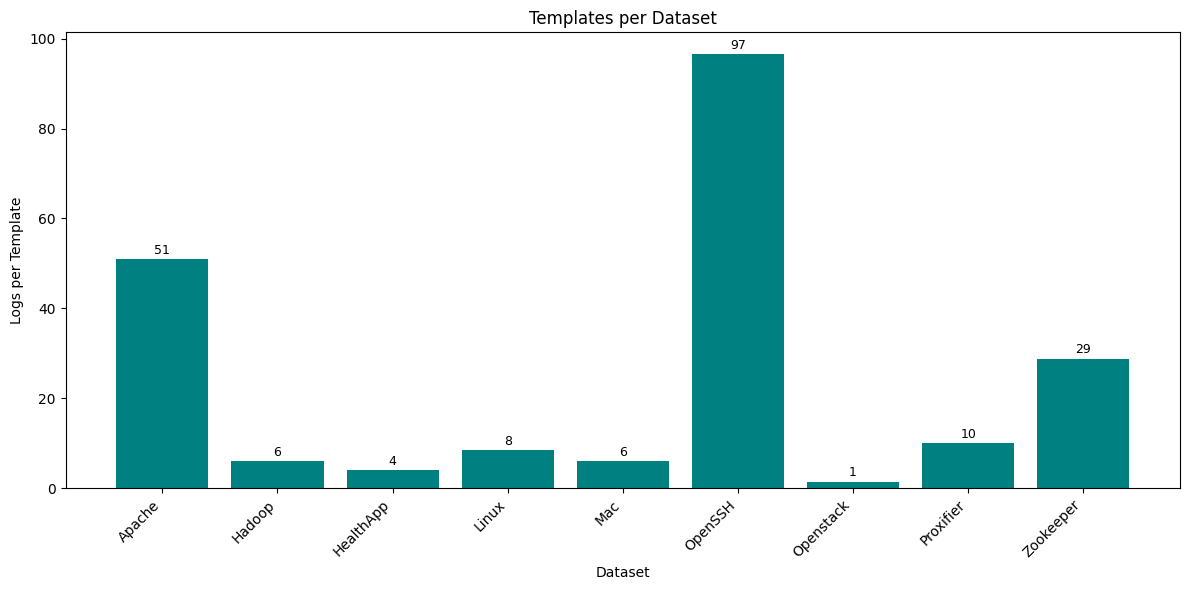

In [19]:
# Analyze template statistics
template_stats = {}

print("Template Analysis:\n")
print(f"{'Dataset':<12} {'Total Logs':>12} {'Templates':>12} {'Logs/Template':>14} {'Top Template':>14}")
print("-" * 68)

for name, templates in template_datasets.items():
    template_counts = Counter(templates)
    total_logs = len(templates)
    num_templates = len(template_counts)
    
    # Compression ratio: how many logs share each template on average
    logs_per_template = total_logs / num_templates
    
    # Top template: what % of logs use the most common template
    top_template_count = template_counts.most_common(1)[0][1]
    top_template_pct = (top_template_count / total_logs) * 100
    
    template_stats[name] = {
        "total_logs": total_logs,
        "num_templates": num_templates,
        "template_counts": template_counts,
        "logs_per_template": logs_per_template,
        "top_template_pct": top_template_pct,
    }
    
    print(f"{name:<12} {total_logs:>12,} {num_templates:>12,} {logs_per_template:>14.1f} {top_template_pct:>13.1f}%")

# Show top 5 templates for each dataset
print("\n\nTop 5 Templates per Dataset:\n")

for name, stats in template_stats.items():
    template_counts = stats["template_counts"]
    total_logs = stats["total_logs"]
    
    print(f"=== {name} ===")
    
    for rank, (template, count) in enumerate(template_counts.most_common(5), 1):
        pct = (count / total_logs) * 100
        template_str = template_to_string(template)
        if len(template_str) > 70:
            template_str = template_str[:70] + "..."
        print(f"  {rank}. ({count:,} logs, {pct:.1f}%) {template_str}")
    
    print()

# Logs per template bar chart 
fig, ax = plt.subplots(figsize=(12, 6))

dataset_names = list(template_stats.keys())
logs_per_template = [template_stats[name]["logs_per_template"] for name in dataset_names]

bars = ax.bar(dataset_names, logs_per_template, color="teal")

ax.set_xlabel("Dataset")
ax.set_ylabel("Logs per Template")
ax.set_title("Templates per Dataset")
ax.set_xticks(range(len(dataset_names)))
ax.set_xticklabels(dataset_names, rotation=45, ha="right")

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.5, f"{height:.0f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

### Compression
Compress logs with schema-based encoding.

Dictionary encoding for templates.

In [21]:
# Template dictionaries for compression (Maps each unique template to an integer ID)

template_dicts = {}

for name, stats in template_stats.items():
    template_counts = stats["template_counts"]
    
    # Sort by frequency
    sorted_templates = [t for t, _ in template_counts.most_common()]
    
    template_to_id = {template: idx for idx, template in enumerate(sorted_templates)}
    id_to_template = {idx: template for template, idx in template_to_id.items()}
    
    template_dicts[name] = {
        "template_to_id": template_to_id,
        "id_to_template": id_to_template,
    }

print(f"Template dictionaries created for {len(template_dicts)} datasets.")

Template dictionaries created for 9 datasets.


In [27]:
# Constants and Configuration Mapping

# Severity list
SEVERITY_LIST = ["INFO", "WARN", "WARNING", "ERROR", "DEBUG", "FATAL", "TRACE", "NOTICE", "CRITICAL", "SEVERE"]
SEVERITY_TO_ID = {s: i for i, s in enumerate(SEVERITY_LIST)}
SEVERITY_FROM_ID = {i: s for i, s in enumerate(SEVERITY_LIST)}

# Type codes
TYPE_TS = 0    # Timestamp
TYPE_SEV = 1   # Severity
TYPE_IP = 2    # IP Address
TYPE_PATH = 3  # File Path
TYPE_VAR = 4   # Other variable (numbers, block IDs, hex, etc.)
TYPE_RAW = 5   # Unknown - store as raw string


In [28]:
# Timestamp conversion function

def timestamp_to_seconds(ts_string):
    formats = [
        "%Y-%m-%d %H:%M:%S",
        "%Y-%m-%dT%H:%M:%S",
        "%Y-%m-%d %H:%M:%S,%f",
        "%H:%M:%S",
        "%H:%M:%S,%f",
    ]
    
    for fmt in formats:
        try:
            dt = datetime.strptime(ts_string, fmt)
            return int(dt.timestamp()) if dt.year > 1970 else int(dt.hour * 3600 + dt.minute * 60 + dt.second)
        except:
            pass
    
    # In case of numeric timestamp (like 081109 for HHMMSS)
    if ts_string.isdigit() and len(ts_string) == 6:
        try:
            h, m, s = int(ts_string[:2]), int(ts_string[2:4]), int(ts_string[4:6])
            return h * 3600 + m * 60 + s
        except:
            pass
    
    return None

In [ ]:
# Compression and Decompression Functions For Templates 
# Instead of storing full template, we build a token dictionary and store templates as lists of token IDs.

def compress_templates(id_to_template):
    # Build token dictionary from all templates
    token_to_id = {}
    for template in id_to_template.values():
        for token in template:
            if token not in token_to_id:
                token_to_id[token] = len(token_to_id)
    
    # Store templates as lists of token IDs
    compressed_templates = {}
    for tid, template in id_to_template.items():
        compressed_templates[tid] = [token_to_id[t] for t in template]
    
    return {
        "tokens": {v: k for k, v in token_to_id.items()},  # id -> token
        "templates": compressed_templates,  # template_id -> [token_ids]
    }


def decompress_templates(compressed_template_data):
    tokens = compressed_template_data["tokens"]
    templates = compressed_template_data["templates"]

    id_to_template = {}
    for tid, token_ids in templates.items():
        id_to_template[int(tid)] = [tokens[str(tok_id)] for tok_id in token_ids]
    
    return id_to_template